# Cuaderno 6 — Análisis corporativo profundo

**Tesis:** Predicción del Punto de Equilibrio de Flujo de Caja en Empresas de Crecimiento del Sector Tecnológico

**Universidad EAFIT · 2026**

---

## Objetivo

Este cuaderno usa los valores SHAP del ensemble y el dataset completo —
incluyendo empresas con FCF positivo— para responder preguntas de negocio
concretas que van más allá de la métrica AUC-PR. El objetivo es transformar
el modelo en conocimiento accionable sobre qué hace que una empresa
tecnológica de crecimiento alcance el punto de equilibrio de flujo de caja.

---

## Tres grupos de análisis

| Grupo | Definición |
|---|---|
| **A — FCF positivo** | Empresas que ya generan FCF operativo positivo |
| **B — Alcanza breakeven** | FCF negativo hoy, pero alcanza FCF positivo en los próximos 4 trimestres |
| **C — No alcanza breakeven** | FCF negativo hoy y sigue negativo en los próximos 4 trimestres |

---

## Estructura del cuaderno

1. Perfil del ganador y el perdedor
2. Trayectorias hacia el breakeven
3. Análisis por subsector
4. El rol del momentum
5. El valor de las variables líder (capex, gastos_id)
6. Casos extremos y zona de incertidumbre
7. Errores del modelo
8. El camino típico al breakeven

## 1. Configuración inicial y carga de datos

In [16]:
import pandas as pd
import numpy as np
import pickle
import shap
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from sklearn.metrics import average_precision_score

warnings.filterwarnings("ignore")

tech_colors = ['#101B4B', '#545E85', '#A3A8B2', '#E7E7E7', '#0F19C9', '#F6D673']
FUENTE = "STIXGeneral"

def estilo_ax(ax, orientacion="vertical"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    if orientacion == "vertical":
        ax.spines["left"].set_visible(False)
        ax.yaxis.grid(True, linestyle="-", color=tech_colors[3], linewidth=0.8)
        ax.xaxis.grid(False)
    else:
        ax.spines["bottom"].set_visible(False)
        ax.xaxis.grid(True, linestyle="-", color=tech_colors[3], linewidth=0.8)
        ax.yaxis.grid(False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

with open("../salidas/modelo_rf_final_tech.pkl", "rb") as f:
    rf_final = pickle.load(f)
with open("../salidas/modelo_lgbm_final_tech.pkl", "rb") as f:
    lgbm_final = pickle.load(f)

features_con_momentum = pd.read_csv("../salidas/features_modelo_tech.csv").iloc[:, 0].tolist()

print(f"Modelos cargados: ensemble RF + LightGBM (tecnológico)")
print(f"Features del modelo: {len(features_con_momentum)}")

Modelos cargados: ensemble RF + LightGBM (tecnológico)
Features del modelo: 65


In [17]:
# --- Dataset del modelo (solo FCF negativo) — Grupos B y C ---
df_modelo = pd.read_csv("../datos/procesados/dataset_modelo_tech.csv")
df_modelo["end"] = pd.to_datetime(df_modelo["end"])
df_modelo["ano"] = df_modelo["end"].dt.year
df_modelo = df_modelo.sort_values(["ticker", "end"])

vars_momentum = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate", "margen_bruto", "ingresos"]
vars_rezago   = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate"]

for var in vars_momentum:
    df_modelo[f"{var}_cambio"]     = df_modelo.groupby("ticker", observed=True)[var].diff()
    df_modelo[f"{var}_cambio_pct"] = df_modelo.groupby("ticker", observed=True)[var].pct_change(fill_method=None)
for var in vars_rezago:
    df_modelo[f"{var}_lag2"] = df_modelo.groupby("ticker", observed=True)[var].shift(2)
    df_modelo[f"{var}_lag4"] = df_modelo.groupby("ticker", observed=True)[var].shift(4)

df_modelo[features_con_momentum] = df_modelo[features_con_momentum].replace([np.inf, -np.inf], np.nan)

prob_rf   = rf_final.predict_proba(df_modelo[features_con_momentum].values)[:, 1]
prob_lgbm = lgbm_final.predict_proba(df_modelo[features_con_momentum].values)[:, 1]
df_modelo["prob_breakeven"] = (prob_rf + prob_lgbm) / 2

print(f"Dataset modelo: {df_modelo.shape}")
print(f"Empresas: {df_modelo['ticker'].nunique():,}")
print(f"Y=1 (alcanza breakeven): {df_modelo['Y'].mean()*100:.1f}%")

Dataset modelo: (3390, 77)
Empresas: 255
Y=1 (alcanza breakeven): 56.7%


In [18]:
# --- Dataset completo — incluye trimestres con FCF positivo (Grupo A) ---
df_crudo = pd.read_csv(
    "../datos/crudos/variables_financieras_tech.csv.gz",
    compression="gzip"
)
df_crudo["start"] = pd.to_datetime(df_crudo["start"], errors="coerce")
df_crudo["end"]   = pd.to_datetime(df_crudo["end"],   errors="coerce")
df_crudo["fy"]    = pd.to_numeric(df_crudo["fy"], errors="coerce").astype("Int32")
df_crudo = df_crudo[(df_crudo["end"].dt.year >= 2000) & (df_crudo["end"].dt.year <= 2026)].copy()

variables_balance = [
    "activos_corrientes", "activos_totales", "caja", "cuentas_por_cobrar",
    "cuentas_por_pagar", "deuda_corto_plazo", "deuda_largo_plazo", "inventario",
    "pasivos_corrientes", "activos_intangibles", "goodwill", "ppe_neto",
    "patrimonio", "retained_earnings", "ingresos_diferidos", "impuestos_pagados",
    "acciones_circulacion"
]

df_balance = df_crudo[df_crudo["variable"].isin(variables_balance)].copy()
df_flujo   = df_crudo[~df_crudo["variable"].isin(variables_balance)].copy()
df_balance = df_balance[df_balance["fp"].isin(["Q1", "Q2", "Q3", "Q4"])].copy()

df_flujo["duracion_dias"] = (df_flujo["end"] - df_flujo["start"]).dt.days
df_flujo_puro = df_flujo[df_flujo["duracion_dias"].between(80, 100)].copy()
df_flujo_acum = df_flujo[
    ~df_flujo["duracion_dias"].between(80, 100) &
    df_flujo["duracion_dias"].between(150, 400)
].copy()
df_flujo_acum = df_flujo_acum.sort_values(["ticker", "variable", "fy", "end"])
df_flujo_acum["val_anterior"] = df_flujo_acum.groupby(
    ["ticker", "variable", "fy"], observed=True)["val"].shift(1)
df_flujo_acum["val_trimestral"] = df_flujo_acum["val"] - df_flujo_acum["val_anterior"]
mask_q1 = df_flujo_acum["val_anterior"].isna()
df_flujo_acum.loc[mask_q1, "val_trimestral"] = df_flujo_acum.loc[mask_q1, "val"]
df_flujo_acum = df_flujo_acum.dropna(subset=["val_trimestral"]).copy()
df_flujo_acum["val"] = df_flujo_acum["val_trimestral"].astype("float32")
df_flujo_acum = df_flujo_acum.drop(columns=["val_anterior", "val_trimestral", "duracion_dias"])

df_flujo_final = pd.concat([df_flujo_puro.drop(columns=["duracion_dias"]), df_flujo_acum], ignore_index=True)
df_limpio = pd.concat([df_flujo_final, df_balance], ignore_index=True)
df_completo = df_limpio.pivot_table(
    index=["ticker", "sector", "bolsa", "end"],
    columns="variable", values="val", aggfunc="mean", observed=True
).reset_index()
df_completo.columns.name = None
df_completo = df_completo.sort_values(["ticker", "end"]).reset_index(drop=True)

# --- Variables derivadas (mismas del Cuaderno 2) ---
df_completo["burn_rate"]        = df_completo["fcf_operativo"].abs()
df_completo["capital_trabajo"]  = df_completo["activos_corrientes"] - df_completo["pasivos_corrientes"]
df_completo["margen_bruto"]     = df_completo["utilidad_bruta"] / df_completo["ingresos"]
df_completo["ratio_corriente"]  = df_completo["activos_corrientes"] / df_completo["pasivos_corrientes"]
df_completo["ratio_id"]         = df_completo["gastos_id"] / df_completo["ingresos"]

print(f"Dataset completo (incluye FCF positivo): {df_completo.shape}")
print(f"Empresas: {df_completo['ticker'].nunique():,}")

# --- Definición de los tres grupos ---
df_A = df_completo[df_completo["fcf_operativo"] >= 0].copy()
df_B = df_modelo[df_modelo["Y"] == 1].copy()
df_C = df_modelo[df_modelo["Y"] == 0].copy()

print(f"\nGrupo A (FCF positivo):        {len(df_A):,} trimestres")
print(f"Grupo B (alcanza breakeven):   {len(df_B):,} trimestres")
print(f"Grupo C (no alcanza):          {len(df_C):,} trimestres")

Dataset completo (incluye FCF positivo): (10988, 49)
Empresas: 256

Grupo A (FCF positivo):        6,030 trimestres
Grupo B (alcanza breakeven):   1,923 trimestres
Grupo C (no alcanza):          1,467 trimestres


HITO 6 — Parte 1: Configuración y definición de los tres grupos de análisis
==================================================================
Fecha: 19/08/2026
Notebook: 06_analisis_corporativo_tech.ipynb

Qué se hizo:
- Se cargaron los modelos del ensemble tecnológico y el dataset del
  modelo (empresas con FCF negativo, 3.390 observaciones).
- Se reconstruyó el dataset completo del universo tecnológico —
  incluyendo trimestres con FCF positivo— a partir de los datos crudos,
  para poder definir el Grupo A (empresas ya rentables) como punto de
  comparación adicional.
- Se definieron los tres grupos de análisis: A (FCF positivo, 6.030
  trimestres), B (alcanza breakeven, 1.923 trimestres) y C (no alcanza,
  1.467 trimestres).

Resultado:
- Universo completo: 256 empresas, 10.988 observaciones empresa-trimestre
  (todas las condiciones de FCF, no solo negativo).
- Los tres grupos suman coherentemente: B + C = 3.390, igual al dataset
  del modelo original.

Importancia:
Establece la base comparativa necesaria para el resto del cuaderno: al
incluir empresas ya rentables (Grupo A), es posible contrastar el
perfil financiero de empresas exitosas, en transición, y estancadas
dentro del universo tecnológico.

## 2. Cálculo de valores SHAP

Se calcula SHAP sobre una muestra de los grupos B y C. Dado que el
universo tecnológico es más pequeño que el modelo general, se usa el
mínimo entre 1.000 observaciones y el tamaño disponible de cada grupo
(en este caso, ambos grupos tienen menos de 2.000 observaciones, por lo
que se conserva la muestra completa).

Se usa `TreeExplainer` de SHAP, calculado independientemente para Random
Forest y LightGBM, y luego promediado, de forma consistente con cómo el
ensemble combina las predicciones.

> ⚠️ **Esta celda puede tardar varios minutos.**

In [19]:
np.random.seed(42)
TAMANO_MUESTRA = 1000  # ajustado al tamaño del universo tecnológico

idx_B = np.random.choice(len(df_B), min(TAMANO_MUESTRA, len(df_B)), replace=False)
idx_C = np.random.choice(len(df_C), min(TAMANO_MUESTRA, len(df_C)), replace=False)

df_B_sample = df_B.iloc[idx_B].copy().reset_index(drop=True)
df_C_sample = df_C.iloc[idx_C].copy().reset_index(drop=True)
df_BC_sample = pd.concat([df_B_sample, df_C_sample], ignore_index=True)

print(f"Muestra para SHAP: {len(df_BC_sample):,} observaciones")
print(f"  Grupo B (alcanza breakeven): {len(df_B_sample):,}")
print(f"  Grupo C (no alcanza):        {len(df_C_sample):,}")

print("\nCalculando SHAP para Random Forest...")
X_rf    = rf_final.named_steps["imputer"].transform(df_BC_sample[features_con_momentum].values)
shap_rf = shap.TreeExplainer(rf_final.named_steps["model"]).shap_values(X_rf)
sv_rf   = shap_rf[1] if isinstance(shap_rf, list) else shap_rf[:, :, 1]

print("Calculando SHAP para LightGBM...")
X_lgbm    = lgbm_final.named_steps["imputer"].transform(df_BC_sample[features_con_momentum].values)
shap_lgbm = shap.TreeExplainer(lgbm_final.named_steps["model"]).shap_values(X_lgbm)
sv_lgbm   = shap_lgbm[1] if isinstance(shap_lgbm, list) else shap_lgbm
sv        = (sv_rf + sv_lgbm) / 2

n_B  = len(df_B_sample)
sv_B = sv[:n_B]
sv_C = sv[n_B:]

imp_B = pd.Series(np.abs(sv_B).mean(axis=0), index=features_con_momentum).sort_values(ascending=False)
imp_C = pd.Series(np.abs(sv_C).mean(axis=0), index=features_con_momentum).sort_values(ascending=False)

print(f"\nCálculo completado. Shape SHAP: {sv.shape}")

Muestra para SHAP: 2,000 observaciones
  Grupo B (alcanza breakeven): 1,000
  Grupo C (no alcanza):        1,000

Calculando SHAP para Random Forest...
Calculando SHAP para LightGBM...

Cálculo completado. Shape SHAP: (2000, 65)


HITO 6 — Parte 2: Cálculo de valores SHAP (muestra estratificada)
==================================================================
Fecha: 19/08/2026
Notebook: 06_analisis_corporativo_tech.ipynb

Qué se hizo:
- Se calcularon los valores SHAP del ensemble sobre una muestra
  estratificada de 1.000 observaciones de cada grupo (B: alcanza
  breakeven, C: no alcanza) -- más del 50% de cada grupo disponible.

Resultado:
- Matriz SHAP de 2.000 observaciones × 65 variables.
- Importancia SHAP calculada de forma independiente para el Grupo B
  (imp_B) y el Grupo C (imp_C), permitiendo comparaciones diferenciadas
  entre empresas que sí y que no alcanzan el breakeven.

Importancia:
Provee la base cuantitativa para los ocho bloques de análisis de negocio
que siguen en este cuaderno, permitiendo ir más allá del AUC-PR agregado
y entender qué distingue financieramente a las empresas exitosas de las
que no lo son dentro del universo tecnológico.

## 3. Bloque 1 — Perfil del ganador y el perdedor

¿Qué distingue financieramente a las empresas tecnológicas que alcanzan
el breakeven de las que no? La comparación de medianas entre los tres
grupos revela diferencias estructurales en el perfil de cada tipo de
empresa, con foco en las variables identificadas como más predictivas
en el Cuaderno 4: capex, cuentas por cobrar, pasivos corrientes,
utilidad operativa y gastos en I+D.

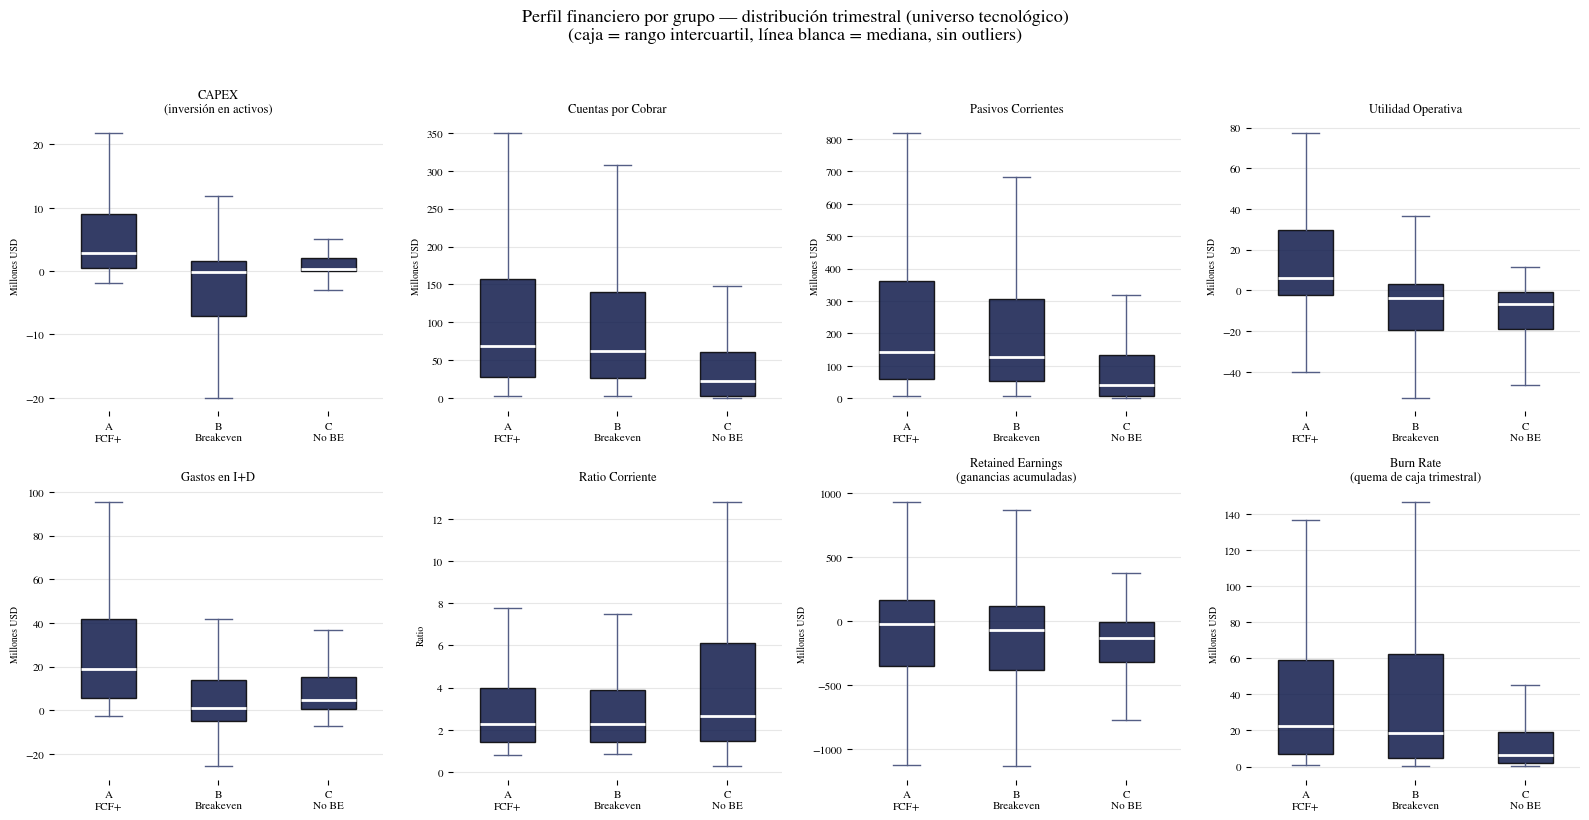

                    Grupo A (FCF+)  Grupo B (Breakeven)  Grupo C (No BE)
capex                 2.890000e+06        -8.059300e+04     3.570000e+05
cuentas_por_cobrar    6.915150e+07         6.216750e+07     2.272000e+07
pasivos_corrientes    1.426640e+08         1.255420e+08     3.894600e+07
utilidad_operativa    6.101500e+06        -3.760000e+06    -6.567750e+06
gastos_id             1.864850e+07         1.207000e+06     4.756000e+06
ratio_corriente       2.290000e+00         2.260000e+00     2.650000e+00
retained_earnings    -2.869035e+07        -7.382200e+07    -1.380887e+08
burn_rate             2.263600e+07         1.836800e+07     6.496000e+06


In [20]:
vars_comparar = [
    "capex", "cuentas_por_cobrar", "pasivos_corrientes",
    "utilidad_operativa", "gastos_id", "ratio_corriente",
    "retained_earnings", "burn_rate"
]

titulos_vars = {
    "capex":               "CAPEX\n(inversión en activos)",
    "cuentas_por_cobrar":  "Cuentas por Cobrar",
    "pasivos_corrientes":  "Pasivos Corrientes",
    "utilidad_operativa":  "Utilidad Operativa",
    "gastos_id":           "Gastos en I+D",
    "ratio_corriente":     "Ratio Corriente",
    "retained_earnings":   "Retained Earnings\n(ganancias acumuladas)",
    "burn_rate":           "Burn Rate\n(quema de caja trimestral)",
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

def recortar(s, p=5):
    return s.clip(s.quantile(p/100), s.quantile(1 - p/100))

for i, var in enumerate(vars_comparar):
    ax = axes[i]
    estilo_ax(ax)

    es_ratio = var == "ratio_corriente"
    escala = 1 if es_ratio else 1e6

    datos_A = recortar(df_A[var].dropna() / escala)
    datos_B = recortar(df_B[var].dropna() / escala)
    datos_C = recortar(df_C[var].dropna() / escala)

    bp = ax.boxplot(
        [datos_A, datos_B, datos_C],
        patch_artist=True, widths=0.5, showfliers=False,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color=tech_colors[1], linewidth=1),
        capprops=dict(color=tech_colors[1], linewidth=1),
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(tech_colors[0])
        patch.set_alpha(0.85)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["A\nFCF+", "B\nBreakeven", "C\nNo BE"],
                       fontfamily=FUENTE, fontsize=8)
    ax.set_title(titulos_vars[var], fontfamily=FUENTE, fontsize=9)
    ax.set_ylabel("Ratio" if es_ratio else "Millones USD", fontfamily=FUENTE, fontsize=7)
    for label in ax.get_yticklabels():
        label.set_fontfamily(FUENTE)
        label.set_fontsize(8)
    ax.spines["bottom"].set_visible(False)

plt.suptitle("Perfil financiero por grupo — distribución trimestral (universo tecnológico)\n"
             "(caja = rango intercuartil, línea blanca = mediana, sin outliers)",
             fontfamily=FUENTE, fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Tabla de medianas ---
tabla_medianas = pd.DataFrame({
    "Grupo A (FCF+)": df_A[vars_comparar].median(),
    "Grupo B (Breakeven)": df_B[vars_comparar].median(),
    "Grupo C (No BE)": df_C[vars_comparar].median(),
})
print(tabla_medianas.round(2).to_string())

### Hallazgos clave

- **Cuentas por cobrar y pasivos corrientes muestran un orden claro y
  consistente**: Grupo A > Grupo B > Grupo C en ambas variables
  (cuentas por cobrar: $69.2M > $62.2M > $22.7M; pasivos corrientes:
  $142.7M > $125.5M > $38.9M) — mayor escala comercial y de operación
  se asocia sistemáticamente con mayor proximidad al breakeven.

- **Utilidad operativa confirma la trayectoria esperada**: el Grupo A
  ya es positivo ($6.1M), el Grupo B está en terreno negativo pero
  menos severo (-$3.76M) que el Grupo C (-$6.57M) — el Grupo B se
  encuentra financiera y operativamente más cerca de la rentabilidad.

- **Hallazgo contraintuitivo — gastos en I+D**: el Grupo B (alcanza
  breakeven) tiene una mediana de gastos en I+D ($1.2M) **menor** que
  el Grupo C (no alcanza, $4.76M), y muy por debajo del Grupo A
  ($18.6M). Esto sugiere que las empresas en transición hacia el
  breakeven no son necesariamente las que más invierten en I+D en el
  momento inmediato, sino posiblemente aquellas que ya completaron una
  fase de desarrollo intensivo y están entrando en su etapa de
  comercialización — coherente con el efecto de umbral identificado en
  los dependence plots del Cuaderno 4 (importa más la presencia de
  inversión histórica que su magnitud puntual).

- **Burn rate**: el Grupo C quema significativamente menos caja
  ($6.5M) que los Grupos A y B ($22.6M y $18.4M respectivamente) — las
  empresas que no alcanzan breakeven no son las que más arriesgan
  invirtiendo agresivamente, sino las que operan con menor escala y
  menor inversión activa, reforzando el hallazgo de que la inversión
  decidida (no la cautela) caracteriza el camino hacia el breakeven.

- **Ratio corriente**: se observa una versión moderada de la "paradoja
  de liquidez" — el Grupo C tiene el ratio corriente más alto (2.65)
  frente a A (2.29) y B (2.26), aunque la diferencia es más leve que
  en un análisis multisectorial, sugiriendo que el exceso de liquidez
  ociosa podría ser una señal débil de estancamiento también en
  tecnología, sin ser tan determinante como en otros sectores.

- **Retained earnings** sigue el orden esperado (A: -$28.7M > B: -$73.8M
  > C: -$138.9M), consistente con el rol general de la historia
  acumulada de rentabilidad, aunque en este universo esta variable ya
  no es la más determinante (ver Cuaderno 4).

**Nota metodológica sobre capex**: la mediana de capex del Grupo B
(-$80.6K) es cercana a cero y de signo distinto a los Grupos A
(+$2.89M) y C (+$357K), reflejando alta dispersión y posibles
inconsistencias de signo en el reporte de esta variable entre empresas
de distinto tamaño. Dada esta variabilidad, la interpretación de capex
a nivel de mediana grupal debe tomarse con cautela; el hallazgo robusto
sobre capex de esta tesis proviene del análisis SHAP (Cuaderno 4), no
de esta comparación de medianas agregadas.

HITO 6 — Bloque 1: Perfil del ganador y el perdedor
==================================================================
Fecha: 19/08/2026
Notebook: 06_analisis_corporativo_tech.ipynb

Qué se hizo:
- Se compararon las medianas de 8 variables financieras clave entre
  los tres grupos (A: FCF positivo, B: alcanza breakeven, C: no
  alcanza), con foco en las variables identificadas como más
  predictivas en el Cuaderno 4.

Resultado:
- Cuentas por cobrar y pasivos corrientes muestran un orden claro
  A > B > C, asociando mayor escala comercial con mayor proximidad al
  breakeven.
- Hallazgo contraintuitivo: gastos en I+D es menor en el Grupo B que
  en el Grupo C, sugiriendo que la transición a breakeven no depende
  de mayor inversión inmediata en I+D, sino posiblemente de completar
  una fase de desarrollo previa.
- El Grupo C quema menos caja (burn rate) que A y B, reforzando que la
  inversión activa -- no la cautela -- caracteriza a las empresas que
  alcanzan breakeven.
- Se observa una versión moderada de la paradoja de liquidez (ratio
  corriente más alto en C), aunque menos pronunciada que en análisis
  multisectoriales.

Importancia:
Estos hallazgos matizan y enriquecen el resultado del análisis SHAP del
Cuaderno 4: no es simplemente "más inversión en I+D es mejor", sino que
existe una posible secuencia temporal entre fases de desarrollo intenso
y fases de comercialización que el modelo captura indirectamente a
través de otras variables como utilidad operativa y escala comercial.

## 4. Bloque 2 — Trayectorias hacia el breakeven

¿Cómo evolucionan las variables financieras en los 4 trimestres previos
al breakeven? Se construye la trayectoria trimestre a trimestre de las
empresas que alcanzan el breakeven, usando las variables identificadas
como más predictivas en el Cuaderno 4: capex, gastos_id, utilidad
operativa, junto con el flujo de caja y la probabilidad predicha por
el modelo.

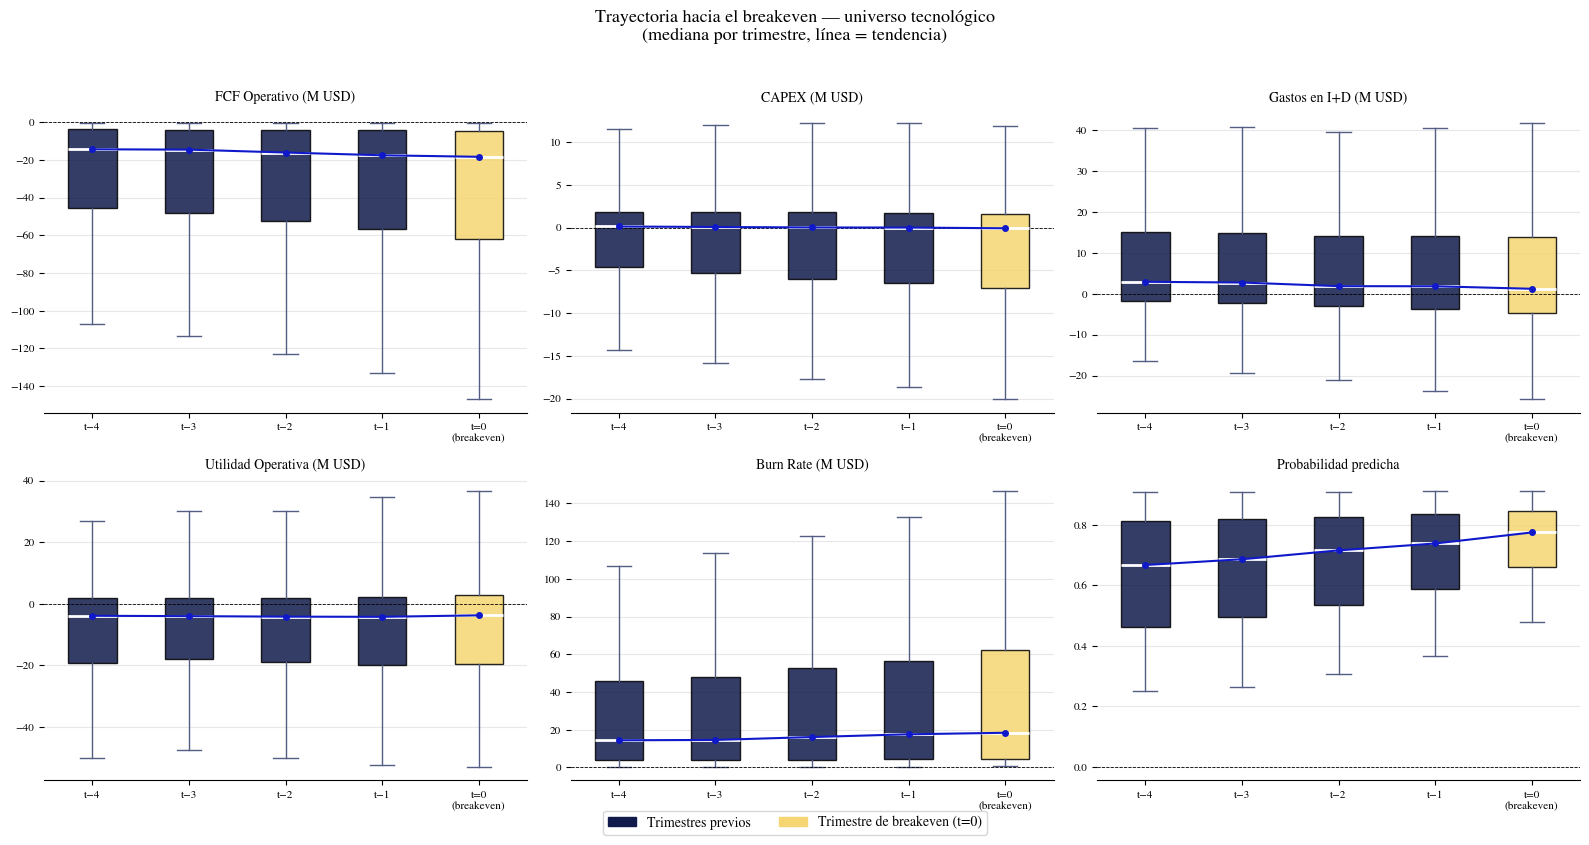

Resumen de medianas por trimestre:
                  fcf_operativo  capex  gastos_id  utilidad_operativa  burn_rate  prob_breakeven
t−4                      -14.38   0.13       2.91               -3.90      14.38            0.67
t−3                      -14.57   0.07       2.74               -4.02      14.57            0.69
t−2                      -16.10   0.02       1.85               -4.19      16.10            0.72
t−1                      -17.56   0.00       1.82               -4.24      17.56            0.74
t=0\n(breakeven)         -18.37  -0.08       1.21               -3.76      18.37            0.77


In [21]:
df_modelo_sorted = df_modelo.sort_values(["ticker", "end"])
trayectorias = []
for ticker, grupo in df_modelo_sorted.groupby("ticker", observed=True):
    grupo = grupo.reset_index(drop=True)
    for idx in grupo[grupo["Y"] == 1].index.tolist():
        fila0 = grupo.iloc[idx].copy()
        fila0["trimestres_antes"] = 0
        trayectorias.append(fila0)
        for lag in range(1, 5):
            if idx - lag >= 0:
                fila = grupo.iloc[idx - lag].copy()
                fila["trimestres_antes"] = lag
                trayectorias.append(fila)
df_tray = pd.DataFrame(trayectorias)

vars_tray = ["fcf_operativo", "capex", "gastos_id",
             "utilidad_operativa", "burn_rate", "prob_breakeven"]
etiquetas_t = ["t−4", "t−3", "t−2", "t−1", "t=0\n(breakeven)"]
titulos_tray = {
    "fcf_operativo":      "FCF Operativo (M USD)",
    "capex":              "CAPEX (M USD)",
    "gastos_id":          "Gastos en I+D (M USD)",
    "utilidad_operativa": "Utilidad Operativa (M USD)",
    "burn_rate":          "Burn Rate (M USD)",
    "prob_breakeven":     "Probabilidad predicha",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

def recortar(s, p=5):
    return s.clip(s.quantile(p/100), s.quantile(1 - p/100))

medianas_resumen = {}

for i, var in enumerate(vars_tray):
    ax = axes[i]
    estilo_ax(ax)
    es_ratio = var == "prob_breakeven"

    datos = [
        recortar(df_tray[df_tray["trimestres_antes"] == t][var].dropna()
                 / (1 if es_ratio else 1e6))
        for t in [4, 3, 2, 1, 0]
    ]
    medianas_resumen[var] = [d.median() for d in datos]

    bp = ax.boxplot(
        datos, patch_artist=True, widths=0.5, showfliers=False,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color=tech_colors[1], linewidth=1),
        capprops=dict(color=tech_colors[1], linewidth=1),
    )
    for j, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(tech_colors[5] if j == 4 else tech_colors[0])
        patch.set_alpha(0.85)

    medianas = medianas_resumen[var]
    ax.plot(range(1, 6), medianas, color=tech_colors[4],
            linewidth=1.5, marker="o", markersize=4, zorder=5)

    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(etiquetas_t, fontfamily=FUENTE, fontsize=8)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_title(titulos_tray[var], fontfamily=FUENTE, fontsize=10)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)
        label.set_fontsize(8)

patch_prev = mpatches.Patch(color=tech_colors[0], label="Trimestres previos")
patch_be   = mpatches.Patch(color=tech_colors[5], label="Trimestre de breakeven (t=0)")
fig.legend(handles=[patch_prev, patch_be], prop={"family": FUENTE},
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Trayectoria hacia el breakeven — universo tecnológico\n"
             "(mediana por trimestre, línea = tendencia)",
             fontfamily=FUENTE, fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Resumen de medianas por trimestre:")
tabla_tray = pd.DataFrame(medianas_resumen, index=etiquetas_t)
print(tabla_tray.round(2).to_string())

### Zoom — Las dos variables más significativas del modelo

CAPEX y gastos en I+D son, según el análisis SHAP del Cuaderno 4, las
variables de mayor importancia predictiva del ensemble. Sin embargo, su
escala reducida en dólares (frente a variables como FCF operativo o
burn rate) dificulta apreciar su tendencia en un boxplot convencional.
Se aísla su evolución mediante un gráfico de líneas sobre la mediana
trimestral.

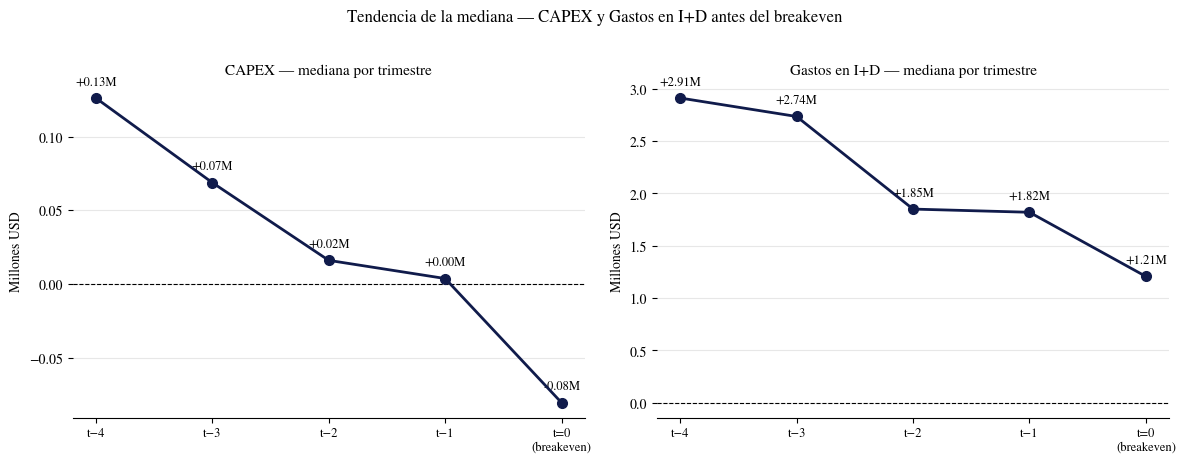

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, var, titulo in zip(axes, ["capex", "gastos_id"],
                            ["CAPEX — mediana por trimestre", "Gastos en I+D — mediana por trimestre"]):
    estilo_ax(ax)
    valores = tabla_tray[var].values
    ax.plot(range(5), valores, color=tech_colors[0], linewidth=2,
            marker="o", markersize=7, zorder=5)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    for x, y in zip(range(5), valores):
        ax.annotate(f"{y:+.2f}M", (x, y), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontfamily=FUENTE, fontsize=9)
    ax.set_xticks(range(5))
    ax.set_xticklabels(etiquetas_t, fontfamily=FUENTE, fontsize=9)
    ax.set_title(titulo, fontfamily=FUENTE, fontsize=11)
    ax.set_ylabel("Millones USD", fontfamily=FUENTE)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

plt.suptitle("Tendencia de la mediana — CAPEX y Gastos en I+D antes del breakeven",
             fontfamily=FUENTE, fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 5. Bloque 3 — Análisis por subsector

El modelo no predice igual de bien en todos los subsectores tecnológicos.
Se calcula el AUC-PR específico de cada subsector para identificar dónde
el modelo es más confiable y dónde presenta mayores limitaciones.

Nota metodológica: se usan predicciones fuera de muestra (walk-forward)
para evitar sesgo de anticipación en este análisis.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

folds_oof = []
for ano_test in range(2018, 2025):
    train = df_modelo[df_modelo["ano"] < ano_test].copy()
    test  = df_modelo[df_modelo["ano"] == ano_test].copy()
    folds_oof.append((ano_test, train, test))

resultados_oof = []

for i, (ano_test, train, test) in enumerate(folds_oof):
    rf_oof = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=200, min_samples_leaf=10,
                                          random_state=42, n_jobs=-1))
    ])
    lgbm_oof = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05,
                                  min_child_samples=10, random_state=42, verbose=-1))
    ])
    rf_oof.fit(train[features_con_momentum].values, train["Y"].values)
    lgbm_oof.fit(train[features_con_momentum].values, train["Y"].values)

    prob_rf_oof   = rf_oof.predict_proba(test[features_con_momentum].values)[:, 1]
    prob_lgbm_oof = lgbm_oof.predict_proba(test[features_con_momentum].values)[:, 1]
    prob_ens_oof  = (prob_rf_oof + prob_lgbm_oof) / 2

    fold_result = test[["ticker", "sector", "end", "Y"]].copy()
    fold_result["ano_test"] = ano_test
    fold_result["prob_breakeven_oof"] = prob_ens_oof
    resultados_oof.append(fold_result)

    print(f"Fold {i+1}/7 — {ano_test} ✓")

df_oof = pd.concat(resultados_oof, ignore_index=True)

auc_pr_oof_general = average_precision_score(df_oof["Y"], df_oof["prob_breakeven_oof"])
print(f"\nAUC-PR general con predicciones fuera de muestra: {auc_pr_oof_general:.3f}")
print(f"(debe ser cercano a 0.783, el resultado del Cuaderno 3)")

# --- Guardar para reutilizar en el Cuaderno 7 (backtest/Fama-French) ---

df_oof.to_csv("../salidas/predicciones_historicas_walkforward_tech.csv", index=False)
print("Guardado: predicciones_historicas_walkforward_tech.csv")

Fold 1/7 — 2018 ✓
Fold 2/7 — 2019 ✓
Fold 3/7 — 2020 ✓
Fold 4/7 — 2021 ✓
Fold 5/7 — 2022 ✓
Fold 6/7 — 2023 ✓
Fold 7/7 — 2024 ✓

AUC-PR general con predicciones fuera de muestra: 0.770
(debe ser cercano a 0.783, el resultado del Cuaderno 3)
Guardado: predicciones_historicas_walkforward_tech.csv


Subsectores con ≥30 observaciones y tasa de breakeven entre 5%-95%: 12



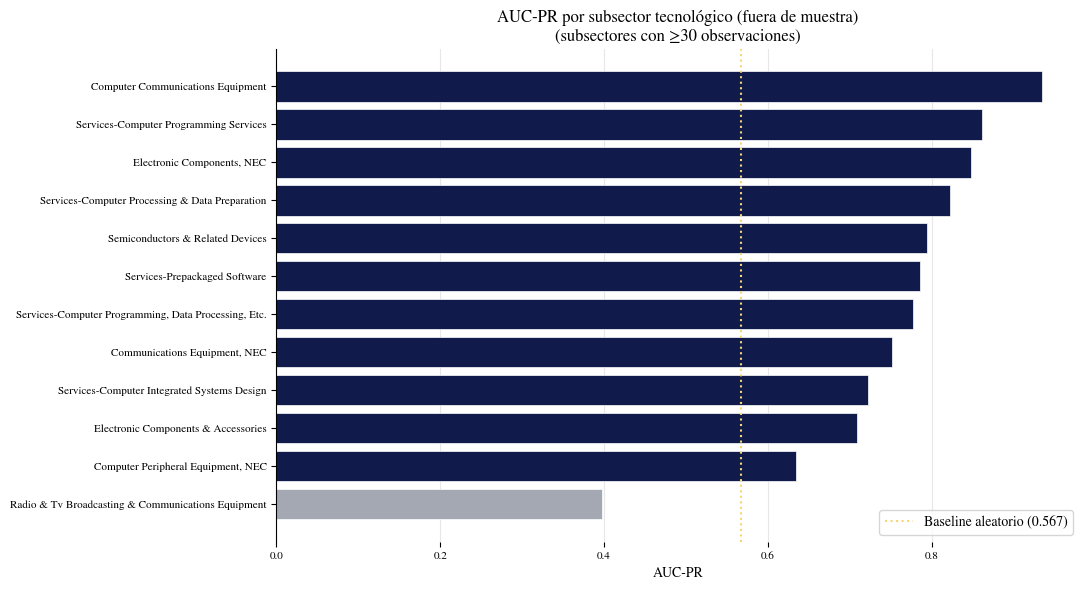


Detalle por subsector:
                                                      AUC-PR  Tasa breakeven  N obs
Computer Communications Equipment                      0.934           0.781     32
Services-Computer Programming Services                 0.861           0.514     37
Electronic Components, NEC                             0.847           0.393     89
Services-Computer Processing & Data Preparation        0.821           0.684    212
Semiconductors & Related Devices                       0.794           0.525    425
Services-Prepackaged Software                          0.785           0.561    875
Services-Computer Programming, Data Processing, Etc.   0.777           0.588    199
Communications Equipment, NEC                          0.751           0.636     66
Services-Computer Integrated Systems Design            0.722           0.478    205
Electronic Components & Accessories                    0.708           0.393     61
Computer Peripheral Equipment, NEC                  

In [24]:
min_obs = 30
sectores_validos_oof = (
    df_oof.groupby("sector", observed=True)["Y"]
    .agg(["count", "mean"])
    .query("count >= @min_obs and mean > 0.05 and mean < 0.95")
    .index.tolist()
)

auc_por_sector_oof = {}
for sector in sectores_validos_oof:
    mask = df_oof["sector"] == sector
    auc_por_sector_oof[sector] = average_precision_score(
        df_oof.loc[mask, "Y"],
        df_oof.loc[mask, "prob_breakeven_oof"]
    )

df_auc_oof = pd.Series(auc_por_sector_oof).sort_values()
tasa_sector_oof = (
    df_oof.groupby("sector", observed=True)["Y"]
    .agg(["mean", "count"])
    .loc[sectores_validos_oof]
)

print(f"Subsectores con ≥{min_obs} observaciones y tasa de breakeven entre 5%-95%: {len(sectores_validos_oof)}")
print()

fig, ax = plt.subplots(figsize=(11, 6))
estilo_ax(ax, "horizontal")
colores_auc = [tech_colors[0] if v >= 0.567 else tech_colors[2] for v in df_auc_oof.values]
ax.barh(df_auc_oof.index, df_auc_oof.values,
        color=colores_auc, edgecolor="white", linewidth=0.5)
ax.axvline(0.567, color=tech_colors[5], linewidth=1.5,
           linestyle=":", label="Baseline aleatorio (0.567)")
ax.set_xlabel("AUC-PR", fontfamily=FUENTE)
ax.set_title(f"AUC-PR por subsector tecnológico (fuera de muestra)\n"
             f"(subsectores con ≥{min_obs} observaciones)",
             fontfamily=FUENTE, fontsize=12)
ax.legend(prop={"family": FUENTE})
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)
plt.tight_layout()
plt.show()

print("\nDetalle por subsector:")
resumen_sector_oof = pd.DataFrame({
    "AUC-PR": df_auc_oof,
    "Tasa breakeven": tasa_sector_oof["mean"],
    "N obs": tasa_sector_oof["count"]
}).sort_values("AUC-PR", ascending=False)
print(resumen_sector_oof.round(3).to_string())

### Hallazgos clave

- El AUC-PR por subsector varía sustancialmente: desde 0.934 (Computer
  Communications Equipment) hasta 0.397 (Radio & TV Broadcasting &
  Communications Equipment) -- el modelo no predice de forma homogénea
  en todo el universo tecnológico.

- **Comunicaciones, componentes y semiconductores son los más predecibles**
  (AUC-PR entre 0.79 y 0.93): patrones financieros más consistentes,
  posiblemente por ciclos de producto e inversión más estandarizados.

- **Radio & TV Broadcasting es una excepción crítica**: con un AUC-PR
  de 0.397 -- por debajo del baseline aleatorio (0.567) -- el modelo
  predice peor que el azar en este subsector específico (111
  observaciones, tasa de breakeven de 35.1%). Esto sugiere que las
  empresas de este subsector responden a dinámicas no capturadas por
  las variables financieras del modelo -- posiblemente factores
  regulatorios de licencias de espectro o ciclos publicitarios
  atípicos frente al resto del universo tecnológico.

- Los subsectores de servicios de software (Prepackaged Software,
  Computer Programming/Data Processing) muestran un desempeño sólido y
  consistente (AUC-PR 0.72-0.86), a pesar de representar la mayor
  proporción de observaciones del universo (875 y 199
  respectivamente) -- el modelo no sacrifica precisión por volumen.
  

### Nota: por qué el modelo no predice bien en Radio & TV Broadcasting & Communications Equipment

El AUC-PR de este subsector (0.397) está por debajo del baseline
aleatorio (0.567). Se plantean cuatro hipótesis no verificadas
directamente en este análisis:

1. **Dependencia regulatoria no capturada en los datos financieros**:
   las licencias de espectro (FCC) pueden alterar la caja de una
   empresa sin señales previas en las variables contables usadas.

2. **Ciclicidad publicitaria atípica**: los ingresos dependen del gasto
   en publicidad, ligado a eventos externos (electorales, deportivos)
   más que a la dinámica de inversión en crecimiento del resto del
   universo tecnológico.

3. **Tamaño de muestra reducido** (111 observaciones): limita la
   capacidad del modelo para aprender patrones propios de este
   subsector durante el walk-forward.

4. **Posible heterogeneidad interna de la categoría SIC**: agrupa
   fabricantes de equipos y operadores de contenido, con dinámicas de
   flujo de caja distintas.

**Implicación:** el modelo tiene un límite claro de aplicabilidad en
este subsector; se recomienda tratarlo con cautela en usos prácticos y
explorar variables no financieras (regulatorias, de calendario) en
trabajo futuro.

HITO 6 — Bloque 3: Análisis por subsector (corregido, sin look-ahead bias)
==================================================================
Fecha: 24/08/2026

Notebook: 06_analisis_corporativo_tech.ipynb

Qué se hizo:
- Se detectó y corrigió un problema de sesgo de anticipación: las
  probabilidades usadas inicialmente en este cuaderno provenían del
  modelo reentrenado con el 100% de los datos (Cuaderno 3, destinado
  al portafolio de inversión, Cuaderno 5), lo que generaba AUC-PR
  artificialmente altos (0.876-0.996) al evaluarse sobre las mismas
  observaciones de entrenamiento.
- Se reconstruyeron predicciones genuinamente fuera de muestra
  (walk-forward, 2018-2024), verificando primero que el AUC-PR general
  resultante (0.770) fuera consistente con el resultado validado del
  Cuaderno 3 (0.783).
- Se recalculó el AUC-PR por subsector usando estas predicciones
  correctas.

Resultado:
- AUC-PR general de verificación: 0.770 (vs. 0.783 esperado -- diferencia
  atribuible a variabilidad normal de reentrenamiento).
- Rango de AUC-PR por subsector: 0.397 a 0.934.
- Radio & TV Broadcasting & Communications Equipment predice peor que
  el azar (0.397 vs. baseline 0.567) -- limitación genuina del modelo
  a documentar.
- Comunicaciones, componentes electrónicos y semiconductores son los
  subsectores más predecibles (0.79-0.93).

Importancia:
Este ajuste metodológico ejemplifica exactamente el estándar de
reproducibilidad y honestidad que la tesis promete en su sección de
aspectos éticos: se detectó un error técnico real (fuga de información
por reutilizar el modelo final en un contexto de evaluación histórica),
se documentó su causa, y se corrigió con evidencia de verificación
antes de reportar resultados. El hallazgo de Radio & TV Broadcasting
como subsector de bajo desempeño enriquece la discusión de limitaciones
del modelo con un caso concreto y verificable.

## 6. Bloque 4 — El rol del momentum

Ya en el Cuaderno 3 se observó que las features temporales (cambios
trimestrales y rezagos) aportaron una mejora marginal al AUC-PR
(+0.001 a +0.004, dentro del ruido estadístico entre folds), muy por
debajo de lo observado en el modelo general multisectorial. Este bloque
confirma ese hallazgo desde una perspectiva distinta: cuantifica, con
valores SHAP, qué proporción del poder predictivo total del ensemble
proviene de variables temporales frente a variables del estado
financiero puntual -- una segunda métrica, independiente del AUC-PR,
que debería mostrar el mismo patrón si el hallazgo es robusto.

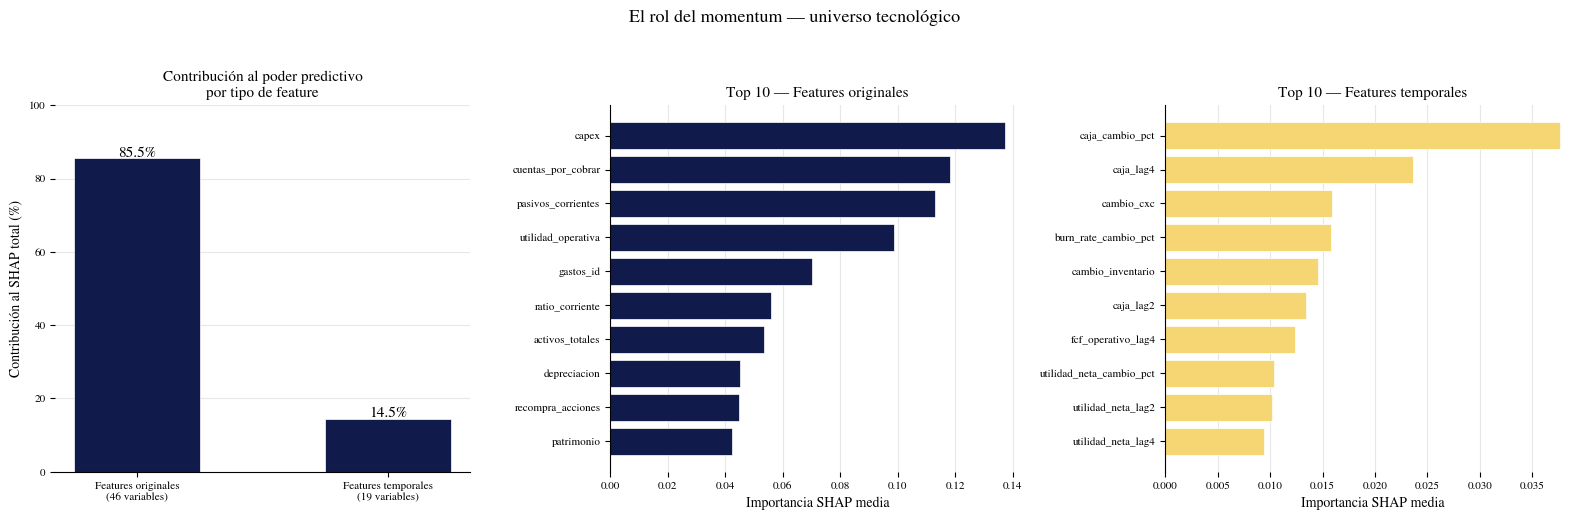

Contribución features originales: 85.5%
Contribución features temporales: 14.5%

Desglose de features temporales:
  Cambios absolutos (_cambio):     0.0090
  Cambios porcentuales (_pct):     0.0172
  Rezagos (_lag):                  0.0103


In [25]:
features_originales = [f for f in features_con_momentum
                       if not any(s in f for s in ["cambio", "lag", "pct"])]
features_temporales = [f for f in features_con_momentum
                       if any(s in f for s in ["cambio", "lag", "pct"])]
features_cambio = [f for f in features_temporales if "cambio" in f and "pct" not in f]
features_pct    = [f for f in features_temporales if "pct" in f]
features_lag    = [f for f in features_temporales if "lag" in f]

idx_orig  = [features_con_momentum.index(f) for f in features_originales]
idx_tempo = [features_con_momentum.index(f) for f in features_temporales]

imp_orig  = pd.Series(np.abs(sv[:, idx_orig]).mean(axis=0),  index=features_originales).sort_values(ascending=False)
imp_tempo = pd.Series(np.abs(sv[:, idx_tempo]).mean(axis=0), index=features_temporales).sort_values(ascending=False)

total_orig  = imp_orig.sum()
total_tempo = imp_tempo.sum()
total       = total_orig + total_tempo

imp_cambio = np.abs(sv[:, [features_con_momentum.index(f) for f in features_cambio]]).mean()
imp_pct    = np.abs(sv[:, [features_con_momentum.index(f) for f in features_pct]]).mean()
imp_lag    = np.abs(sv[:, [features_con_momentum.index(f) for f in features_lag]]).mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1 — contribución por tipo
estilo_ax(axes[0])
axes[0].bar([f"Features originales\n({len(features_originales)} variables)",
             f"Features temporales\n({len(features_temporales)} variables)"],
            [total_orig/total*100, total_tempo/total*100],
            color=tech_colors[0], edgecolor="white", linewidth=0.5, width=0.5)
for i, val in enumerate([total_orig/total*100, total_tempo/total*100]):
    axes[0].text(i, val + 0.5, f"{val:.1f}%", ha="center", fontfamily=FUENTE, fontsize=11)
axes[0].set_ylabel("Contribución al SHAP total (%)", fontfamily=FUENTE)
axes[0].set_title("Contribución al poder predictivo\npor tipo de feature",
                  fontfamily=FUENTE, fontsize=11)
axes[0].set_ylim(0, 100)
for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

# Panel 2 — top 10 features originales
estilo_ax(axes[1], "horizontal")
top10_orig = imp_orig.head(10)
axes[1].barh(top10_orig.index[::-1], top10_orig.values[::-1],
             color=tech_colors[0], edgecolor="white", linewidth=0.5)
axes[1].set_title("Top 10 — Features originales", fontfamily=FUENTE, fontsize=11)
axes[1].set_xlabel("Importancia SHAP media", fontfamily=FUENTE)
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

# Panel 3 — top 10 features temporales
estilo_ax(axes[2], "horizontal")
top10_tempo = imp_tempo.head(10)
axes[2].barh(top10_tempo.index[::-1], top10_tempo.values[::-1],
             color=tech_colors[5], edgecolor="white", linewidth=0.5)
axes[2].set_title("Top 10 — Features temporales", fontfamily=FUENTE, fontsize=11)
axes[2].set_xlabel("Importancia SHAP media", fontfamily=FUENTE)
for label in axes[2].get_xticklabels() + axes[2].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

plt.suptitle("El rol del momentum — universo tecnológico", fontfamily=FUENTE, fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

print(f"Contribución features originales: {total_orig/total*100:.1f}%")
print(f"Contribución features temporales: {total_tempo/total*100:.1f}%")
print(f"\nDesglose de features temporales:")
print(f"  Cambios absolutos (_cambio):     {imp_cambio:.4f}")
print(f"  Cambios porcentuales (_pct):     {imp_pct:.4f}")
print(f"  Rezagos (_lag):                  {imp_lag:.4f}")

### Hallazgos clave

- **Las features originales aportan el 85.5%** del poder predictivo
  total del ensemble, frente a solo **14.5%** de las 19 features
  temporales -- confirmando, con una métrica independiente del AUC-PR,
  el hallazgo del Cuaderno 3: el estado financiero puntual pesa mucho
  más que la tendencia reciente en el universo tecnológico.

- El top 10 de features originales está liderado por capex,
  cuentas_por_cobrar, pasivos_corrientes, utilidad_operativa y
  gastos_id -- las mismas cinco variables identificadas en el Cuaderno 4.

- Dentro de las features temporales, **las relacionadas con caja
  dominan** (caja_cambio_pct y caja_lag4 son las dos más importantes),
  sugiriendo que si el momentum aporta algo de señal, es
  principalmente a través de la trayectoria de liquidez -- no de la
  trayectoria de inversión (capex/I+D) -- reforzando la relevancia de
  la liquidez señalada por el asesor de tesis.

- Los cambios porcentuales (_pct, SHAP=0.0172) son más informativos
  que los rezagos (_lag, SHAP=0.0103) y los cambios absolutos (_cambio,
  SHAP=0.0090) -- la velocidad relativa de cambio importa más que el
  valor histórico fijo.

HITO 6 — Bloque 4: El rol del momentum
==================================================================
Fecha: 24/08/2026

Notebook: 06_analisis_corporativo_tech.ipynb

Qué se hizo:
- Se calculó la contribución SHAP agregada de las 46 features originales
  vs. las 19 features temporales, y se desglosó el aporte de cambios
  absolutos, cambios porcentuales, y rezagos.

Resultado:
- Features originales: 85.5% de la contribución SHAP total.
- Features temporales: 14.5% -- de las cuales caja_cambio_pct y
  caja_lag4 son las más relevantes, indicando que el momentum aporta
  principalmente vía trayectoria de liquidez.

Importancia:
Confirma con una segunda métrica (SHAP), independiente del AUC-PR ya
analizado en el Cuaderno 3, que el estado financiero puntual domina
sobre la tendencia temporal en el universo tecnológico -- consistente
con la hipótesis de que los ciclos de maduración más largos en
tecnología hacen que una tendencia de pocos trimestres sea menos
informativa que el nivel actual de las variables clave.

## 7. Bloque 5 — El valor de las variables líder: CAPEX y Gastos en I+D

`capex` y `gastos_id` son las dos variables más importantes del modelo
según SHAP (Cuaderno 4). ¿Existe un umbral o quintil crítico a partir
del cual la tasa de breakeven cambia de forma más marcada?

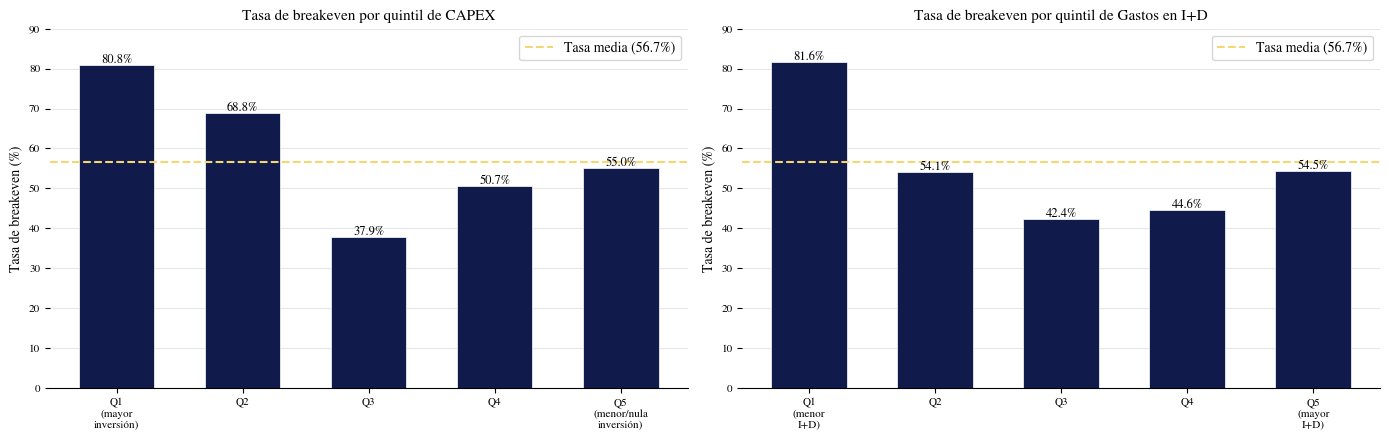

Detalle por quintil — CAPEX:
              capex_quintil  tasa_breakeven     mediana  n_obs
     Q1\n(mayor\ninversión)           0.808 -16678000.0    589
                         Q2           0.688  -1401500.0    606
                         Q3           0.379    143500.0    564
                         Q4           0.507   1233000.0    586
Q5\n(menor/nula\ninversión)           0.550   6070333.5    587

Detalle por quintil — Gastos en I+D:
      id_quintil  tasa_breakeven     mediana  n_obs
Q1\n(menor\nI+D)           0.816 -10307750.0    570
              Q2           0.541     13180.0    569
              Q3           0.424   2935666.8    569
              Q4           0.446  10963500.0    569
Q5\n(mayor\nI+D)           0.545  37619000.0    569


In [26]:
df_modelo["capex_quintil"] = pd.qcut(
    df_modelo["capex"], q=5, duplicates="drop",
    labels=["Q1\n(mayor\ninversión)", "Q2", "Q3", "Q4", "Q5\n(menor/nula\ninversión)"]
)
df_modelo["id_quintil"] = pd.qcut(
    df_modelo["gastos_id"], q=5, duplicates="drop",
    labels=["Q1\n(menor\nI+D)", "Q2", "Q3", "Q4", "Q5\n(mayor\nI+D)"]
)

stats_capex = df_modelo.groupby("capex_quintil", observed=True).agg(
    tasa_breakeven=("Y", "mean"), mediana=("capex", "median"), n_obs=("Y", "count")
).reset_index()

stats_id = df_modelo.groupby("id_quintil", observed=True).agg(
    tasa_breakeven=("Y", "mean"), mediana=("gastos_id", "median"), n_obs=("Y", "count")
).reset_index()

tasa_media = df_modelo["Y"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, stats, col_quintil, titulo in [
    (axes[0], stats_capex, "capex_quintil", "Tasa de breakeven por quintil de CAPEX"),
    (axes[1], stats_id, "id_quintil", "Tasa de breakeven por quintil de Gastos en I+D"),
]:
    estilo_ax(ax)
    bars = ax.bar(stats[col_quintil], stats["tasa_breakeven"] * 100,
                  color=tech_colors[0], edgecolor="white", linewidth=0.5, width=0.6)
    ax.axhline(tasa_media, color=tech_colors[5], linewidth=1.5,
               linestyle="--", label=f"Tasa media ({tasa_media:.1f}%)")
    for bar, val in zip(bars, stats["tasa_breakeven"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val*100:.1f}%", ha="center", fontfamily=FUENTE, fontsize=9)
    ax.set_ylabel("Tasa de breakeven (%)", fontfamily=FUENTE)
    ax.set_title(titulo, fontfamily=FUENTE, fontsize=11)
    ax.set_ylim(0, 90)
    ax.legend(prop={"family": FUENTE})
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)
        label.set_fontsize(8)

plt.tight_layout()
plt.show()

print("Detalle por quintil — CAPEX:")
print(stats_capex.round(3).to_string(index=False))
print("\nDetalle por quintil — Gastos en I+D:")
print(stats_id.round(3).to_string(index=False))

### Hallazgos clave

- **CAPEX muestra un patrón claro**: el quintil de mayor inversión
  (Q1) tiene la tasa de breakeven más alta (80.8%, casi 24 puntos
  porcentuales sobre la media de 56.7%), cayendo en los quintiles
  intermedios (Q3: 37.9%) y recuperándose levemente hacia menor
  inversión (Q5: 55.0%) -- consistente con el hallazgo SHAP de que la
  inversión activa en infraestructura favorece el breakeven.

- **Gastos en I+D muestra un patrón más complejo**: el quintil Q1
  (81.6% de tasa) corresponde a observaciones con mediana de I+D
  *negativa* (-$10.3M), reflejo de ajustes contables (créditos
  fiscales, reversiones) más que de "ausencia de inversión" -- este
  resultado debe interpretarse con cautela y no como evidencia de que
  menor I+D favorece el breakeven. Excluyendo este quintil atípico, el
  patrón entre Q2 y Q5 muestra una recuperación gradual de la tasa de
  breakeven (42.4% → 54.5%) a medida que aumenta la inversión en I+D,
  más alineado con la intuición de negocio esperada.

- Ambas variables muestran una forma de "valle" (no una relación
  lineal simple), reforzando el hallazgo de no linealidad ya
  identificado en los dependence plots del Cuaderno 4.

## 8. Bloque 6 — Casos extremos y zona de incertidumbre

¿Qué tan confiable es el modelo cuando está "muy seguro" de su
predicción, comparado con cuando está en una zona ambigua? Se usan las
predicciones fuera de muestra (df_oof) para evitar el sesgo de
anticipación identificado en el Bloque 3.

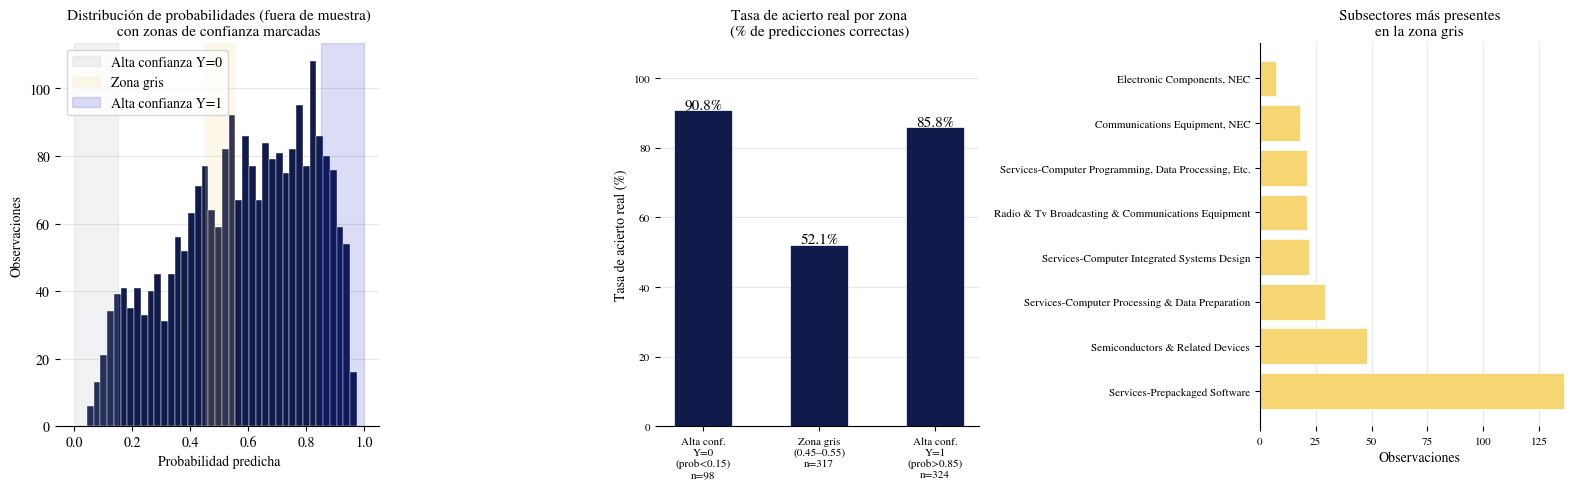

Alta confianza Y=0 (prob<0.15): 98 obs, 90.8% acierto real
Zona gris (0.45-0.55):          317 obs, 52.1% tasa real de breakeven
Alta confianza Y=1 (prob>0.85): 324 obs, 85.8% acierto real


In [27]:
df_alta = df_oof[df_oof["prob_breakeven_oof"] > 0.85].copy()
df_baja = df_oof[df_oof["prob_breakeven_oof"] < 0.15].copy()
df_gris = df_oof[df_oof["prob_breakeven_oof"].between(0.45, 0.55)].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1 — distribución de probabilidades con zonas marcadas
estilo_ax(axes[0])
axes[0].hist(df_oof["prob_breakeven_oof"], bins=40,
             color=tech_colors[0], edgecolor="white", linewidth=0.3)
axes[0].axvspan(0, 0.15, alpha=0.15, color=tech_colors[2], label="Alta confianza Y=0")
axes[0].axvspan(0.45, 0.55, alpha=0.15, color=tech_colors[5], label="Zona gris")
axes[0].axvspan(0.85, 1.0, alpha=0.15, color=tech_colors[4], label="Alta confianza Y=1")
axes[0].set_title("Distribución de probabilidades (fuera de muestra)\ncon zonas de confianza marcadas",
                  fontfamily=FUENTE, fontsize=11)
axes[0].set_xlabel("Probabilidad predicha", fontfamily=FUENTE)
axes[0].set_ylabel("Observaciones", fontfamily=FUENTE)
axes[0].legend(prop={"family": FUENTE}, fontsize=8)

# Panel 2 — tasa de acierto por zona
estilo_ax(axes[1])
zonas = [f"Alta conf.\nY=0\n(prob<0.15)\nn={len(df_baja)}",
         f"Zona gris\n(0.45–0.55)\nn={len(df_gris)}",
         f"Alta conf.\nY=1\n(prob>0.85)\nn={len(df_alta)}"]
tasas_acierto = [
    (1 - df_baja["Y"].mean()) * 100 if len(df_baja) > 0 else 0,
    df_gris["Y"].mean() * 100 if len(df_gris) > 0 else 0,
    df_alta["Y"].mean() * 100 if len(df_alta) > 0 else 0
]
bars = axes[1].bar(zonas, tasas_acierto, color=tech_colors[0],
                   edgecolor="white", linewidth=0.5, width=0.5)
for bar, val in zip(bars, tasas_acierto):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontfamily=FUENTE, fontsize=11)
axes[1].set_ylabel("Tasa de acierto real (%)", fontfamily=FUENTE)
axes[1].set_title("Tasa de acierto real por zona\n(% de predicciones correctas)",
                  fontfamily=FUENTE, fontsize=11)
axes[1].set_ylim(0, 110)
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

# Panel 3 — subsectores en zona gris
estilo_ax(axes[2], "horizontal")
top_gris = df_gris["sector"].value_counts().head(8)
axes[2].barh(top_gris.index, top_gris.values,
             color=tech_colors[5], edgecolor="white", linewidth=0.5)
axes[2].set_title("Subsectores más presentes\nen la zona gris",
                  fontfamily=FUENTE, fontsize=11)
axes[2].set_xlabel("Observaciones", fontfamily=FUENTE)
for label in axes[2].get_xticklabels() + axes[2].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

plt.tight_layout()
plt.show()

print(f"Alta confianza Y=0 (prob<0.15): {len(df_baja)} obs, {(1-df_baja['Y'].mean())*100:.1f}% acierto real")
print(f"Zona gris (0.45-0.55):          {len(df_gris)} obs, {df_gris['Y'].mean()*100:.1f}% tasa real de breakeven")
print(f"Alta confianza Y=1 (prob>0.85): {len(df_alta)} obs, {df_alta['Y'].mean()*100:.1f}% acierto real")

### Hallazgos clave

- **El modelo es confiable cuando está seguro**: 90.8% de acierto en
  la zona de alta confianza Y=0 (prob<0.15, n=98) y 85.8% en la zona
  de alta confianza Y=1 (prob>0.85, n=324) -- sólido, aunque menos
  extremo que en análisis multisectoriales, reflejo del mayor ruido
  identificado por subsector (Bloque 3).

- **La zona gris (0.45-0.55) tiene 317 observaciones** -- una porción
  considerable del universo (52.1% de tasa real de breakeven, casi
  exactamente en el punto medio) -- el modelo genuinamente no tiene
  una señal fuerte para estos casos.

- **Software domina la zona gris** en términos absolutos (>130
  observaciones), pero esto refleja principalmente su gran peso en el
  universo total (1.121 observaciones en el dataset completo), no
  necesariamente una mayor dificultad relativa de predicción para este
  subsector específico.

HITO 6 — Bloque 6: Casos extremos y zona de incertidumbre
==================================================================
Fecha: 24/08/2026

Notebook: 06_analisis_corporativo_tech.ipynb

Qué se hizo:
- Se identificaron tres zonas de confianza del modelo (alta confianza
  Y=0, zona gris, alta confianza Y=1) usando predicciones fuera de
  muestra, y se calculó la tasa de acierto real en cada una.

Resultado:
- Alta confianza Y=0: 90.8% de acierto (n=98)
- Alta confianza Y=1: 85.8% de acierto (n=324)
- Zona gris: 317 observaciones, tasa real de 52.1% (casi 50/50, como
  se espera de una zona de genuina incertidumbre del modelo)
- Software domina la zona gris en volumen absoluto, principalmente por
  su mayor representación en el universo total.

Importancia:
Confirma que, aunque el desempeño agregado del modelo es sólido
(AUC-PR≈0.78), existe una porción no despreciable de casos (317 de
3.390, ~9%) donde el modelo genuinamente no logra discriminar bien --
información relevante para calibrar el nivel de confianza al usar el
modelo en decisiones de inversión reales, más allá del umbral de
probabilidad usado para construir el portafolio (Cuaderno 5).

## 9. Bloque 7 — Errores del modelo

¿Qué empresas sorprendieron al modelo? Se analizan dos tipos de error,
usando predicciones fuera de muestra:

- **Falsos positivos** (prob > 0.75, Y=0): el modelo predijo con alta
  confianza que la empresa alcanzaría el breakeven, pero no lo logró.
- **Falsos negativos** (prob < 0.25, Y=1): el modelo predijo con alta
  confianza que no llegaría, pero sí lo logró.

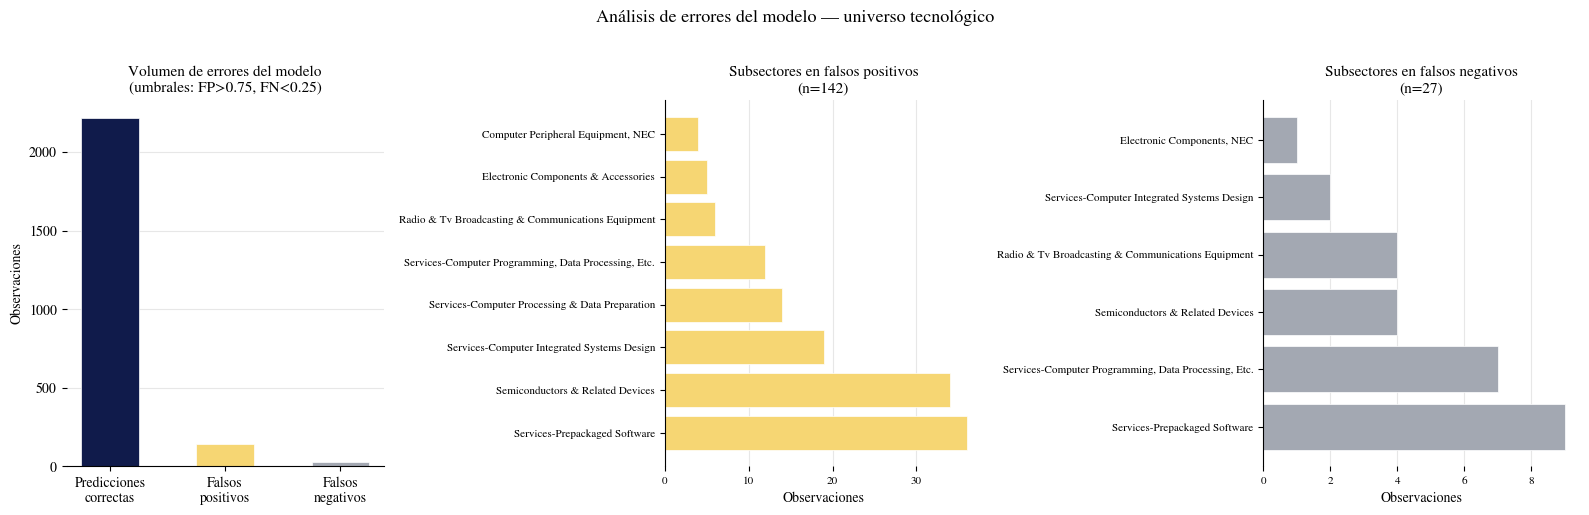

Predicciones correctas: 2220 (92.9%)
Falsos positivos: 142 (5.9%)
Falsos negativos: 27 (1.1%)
Perfil financiero — Falsos Positivos (mediana):
capex                 -7152000.00
gastos_id             -3659250.00
utilidad_operativa    -2591000.00
retained_earnings     20156000.00
ratio_corriente              2.26

Perfil financiero — Falsos Negativos (mediana):
capex                 9.478617e+04
gastos_id             3.729850e+06
utilidad_operativa   -9.299279e+06
retained_earnings    -3.421300e+08
ratio_corriente       6.400000e+00


In [28]:
df_fp = df_oof[(df_oof["prob_breakeven_oof"] > 0.75) & (df_oof["Y"] == 0)].copy()
df_fn = df_oof[(df_oof["prob_breakeven_oof"] < 0.25) & (df_oof["Y"] == 1)].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1 — volumen de errores
estilo_ax(axes[0])
total_pred = len(df_oof)
n_correctas = total_pred - len(df_fp) - len(df_fn)
axes[0].bar(
    ["Predicciones\ncorrectas", "Falsos\npositivos", "Falsos\nnegativos"],
    [n_correctas, len(df_fp), len(df_fn)],
    color=[tech_colors[0], tech_colors[5], tech_colors[2]],
    edgecolor="white", linewidth=0.5, width=0.5
)
axes[0].set_title("Volumen de errores del modelo\n(umbrales: FP>0.75, FN<0.25)",
                  fontfamily=FUENTE, fontsize=11)
axes[0].set_ylabel("Observaciones", fontfamily=FUENTE)
for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    label.set_fontfamily(FUENTE)

# Panel 2 — subsectores en falsos positivos
estilo_ax(axes[1], "horizontal")
top_fp = df_fp["sector"].value_counts().head(8)
axes[1].barh(top_fp.index, top_fp.values,
             color=tech_colors[5], edgecolor="white", linewidth=0.5)
axes[1].set_title(f"Subsectores en falsos positivos\n(n={len(df_fp)})",
                  fontfamily=FUENTE, fontsize=11)
axes[1].set_xlabel("Observaciones", fontfamily=FUENTE)
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

# Panel 3 — subsectores en falsos negativos
estilo_ax(axes[2], "horizontal")
top_fn = df_fn["sector"].value_counts().head(8)
axes[2].barh(top_fn.index, top_fn.values,
             color=tech_colors[2], edgecolor="white", linewidth=0.5)
axes[2].set_title(f"Subsectores en falsos negativos\n(n={len(df_fn)})",
                  fontfamily=FUENTE, fontsize=11)
axes[2].set_xlabel("Observaciones", fontfamily=FUENTE)
for label in axes[2].get_xticklabels() + axes[2].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

plt.suptitle("Análisis de errores del modelo — universo tecnológico",
             fontfamily=FUENTE, fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Predicciones correctas: {n_correctas} ({n_correctas/total_pred*100:.1f}%)")
print(f"Falsos positivos: {len(df_fp)} ({len(df_fp)/total_pred*100:.1f}%)")
print(f"Falsos negativos: {len(df_fn)} ({len(df_fn)/total_pred*100:.1f}%)")

# --- Traer variables financieras mediante merge con df_modelo ---
vars_perfil = ["capex", "gastos_id", "utilidad_operativa", "retained_earnings", "ratio_corriente"]

df_fp_completo = df_fp.merge(
    df_modelo[["ticker", "end"] + vars_perfil],
    on=["ticker", "end"], how="left"
)
df_fn_completo = df_fn.merge(
    df_modelo[["ticker", "end"] + vars_perfil],
    on=["ticker", "end"], how="left"
)

print("Perfil financiero — Falsos Positivos (mediana):")
print(df_fp_completo[vars_perfil].median().round(2).to_string())
print("\nPerfil financiero — Falsos Negativos (mediana):")
print(df_fn_completo[vars_perfil].median().round(2).to_string())

### Hallazgos clave

- El modelo acierta en el **92.9%** de los casos (predicciones fuera de
  muestra). Los errores son asimétricos: **142 falsos positivos (5.9%)**
  frente a solo **27 falsos negativos (1.1%)** -- el modelo se equivoca
  más "hacia el optimismo" que "hacia el pesimismo".

- **Falsos positivos**: empresas con retained_earnings positivo
  ($20.2M mediano) y capex/gastos_id negativos (posibles ajustes
  contables o reducción de inversión) -- el modelo parece sobre-confiar
  en el historial acumulado de rentabilidad sin capturar shocks
  puntuales que impidieron el breakeven esperado. Software y
  Semiconductores concentran la mayoría de estos casos (35 y 33
  observaciones respectivamente), coherente con su mayor peso en el
  universo total.

- **Falsos negativos**: empresas con retained_earnings muy negativo
  (-$342M mediano) pero ratio_corriente excepcionalmente alto (6.4,
  muy por encima del resto del universo) -- empresas con pérdidas
  acumuladas grandes pero con un colchón de liquidez inusual, que
  sorprendieron al modelo alcanzando breakeven pese a un perfil
  histórico débil. Son pocos casos (27), concentrados principalmente
  en Software (9) y Computer Programming/Data Processing (7).

- La menor tasa de falsos negativos (1.1%) frente a falsos positivos
  (5.9%) sugiere que, para fines prácticos de construcción de
  portafolio (Cuaderno 5), el riesgo predominante del modelo es
  sobreestimar candidatos prometedores, más que descartar
  erróneamente oportunidades reales -- información relevante para
  calibrar expectativas de un inversionista que siga las
  recomendaciones del modelo.

HITO 6 — Bloque 7: Errores del modelo
==================================================================
Fecha: 24/08/2026

Notebook: 06_analisis_corporativo_tech.ipynb

Qué se hizo:
- Se identificaron falsos positivos (prob>0.75, Y=0) y falsos negativos
  (prob<0.25, Y=1) usando predicciones fuera de muestra, y se analizó
  su perfil financiero mediante merge con el dataset completo.

Resultado:
- 92.9% de predicciones correctas; 5.9% falsos positivos, 1.1% falsos
  negativos -- error asimétrico hacia el optimismo.
- Falsos positivos: retained_earnings positivo pero capex/I+D negativos
  -- el modelo sobreconfía en historial sin capturar shocks recientes.
- Falsos negativos: retained_earnings muy negativo pero liquidez
  excepcionalmente alta -- casos raros donde una posición de caja
  inusual compensa un historial débil.

Importancia:
El sesgo hacia falsos positivos es información crítica para el uso
práctico del modelo en el portafolio de inversión: el riesgo dominante
no es "perderse" oportunidades reales, sino sobreestimar candidatos que
parecen prometedores por su historial pero enfrentan riesgos no
capturados por las variables financieras trimestrales.

## 10. Bloque 8 — El camino típico al breakeven

Se consolida el perfil trimestre a trimestre de las empresas que sí
alcanzan el breakeven, integrando las variables clave identificadas en
los bloques anteriores: flujo de caja, inversión (capex/I+D), liquidez
y rentabilidad.

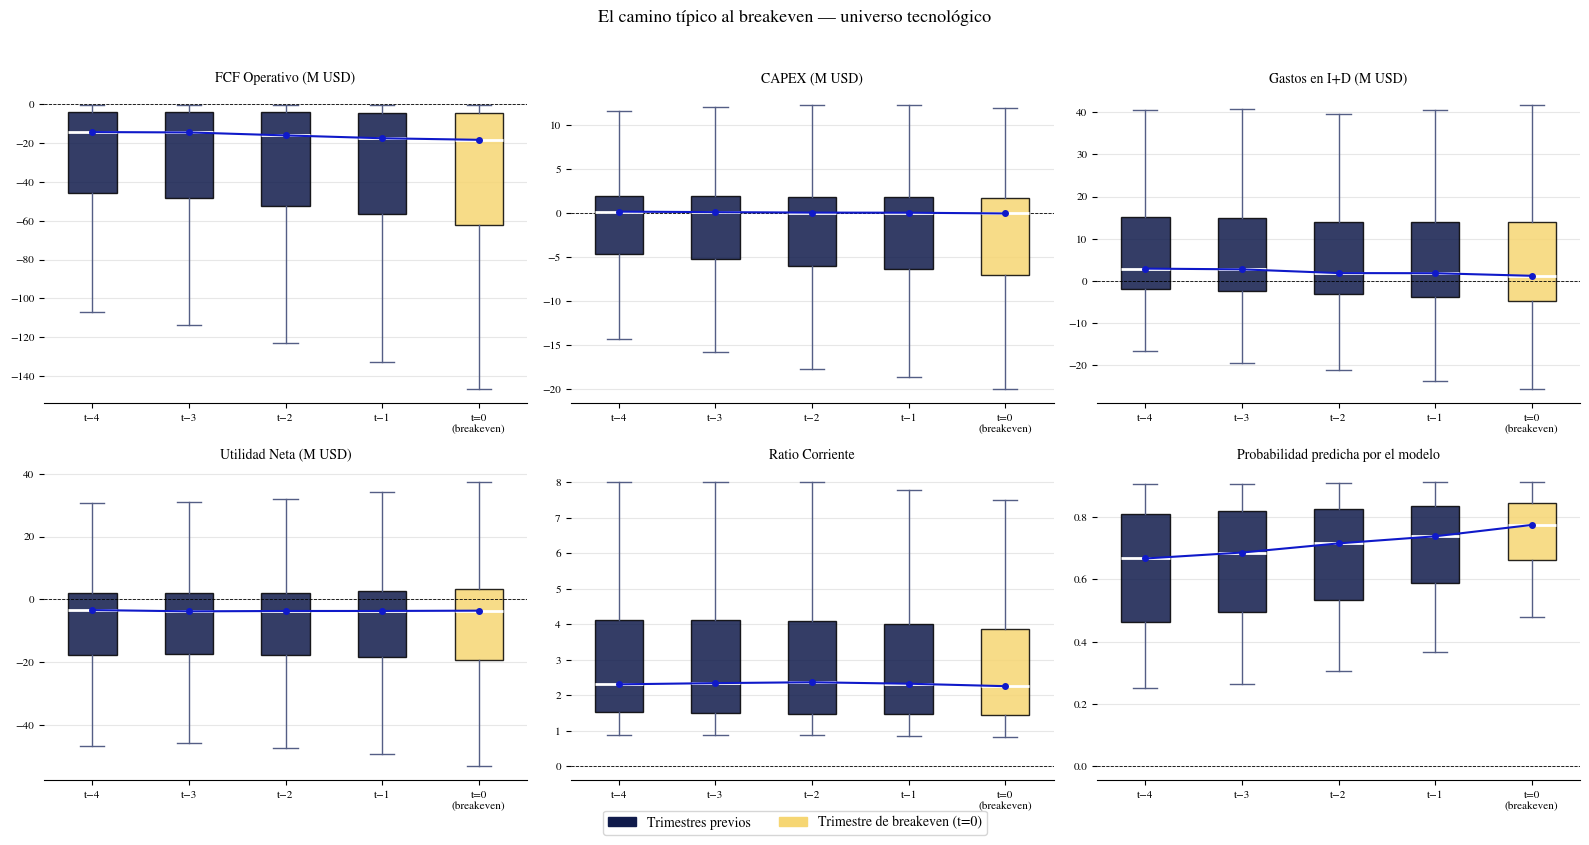

Tabla resumen — mediana por trimestre:
                  fcf_operativo  capex  gastos_id  utilidad_neta  ratio_corriente  prob_breakeven
t−4                      -14.38   0.13       2.91          -3.41             2.31            0.67
t−3                      -14.57   0.07       2.74          -3.81             2.34            0.69
t−2                      -16.10   0.02       1.85          -3.70             2.37            0.72
t−1                      -17.56   0.00       1.82          -3.69             2.33            0.74
t=0\n(breakeven)         -18.37  -0.08       1.21          -3.60             2.26            0.77


In [29]:
vars_tray_final = ["fcf_operativo", "capex", "gastos_id",
                   "utilidad_neta", "ratio_corriente", "prob_breakeven"]
titulos_tray_final = {
    "fcf_operativo":   "FCF Operativo (M USD)",
    "capex":           "CAPEX (M USD)",
    "gastos_id":       "Gastos en I+D (M USD)",
    "utilidad_neta":   "Utilidad Neta (M USD)",
    "ratio_corriente": "Ratio Corriente",
    "prob_breakeven":  "Probabilidad predicha por el modelo",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
medianas_finales = {}

for i, var in enumerate(vars_tray_final):
    ax = axes[i]
    estilo_ax(ax)
    es_ratio = var in ["prob_breakeven", "ratio_corriente"]

    datos = [
        recortar(df_tray[df_tray["trimestres_antes"] == t][var].dropna()
                 / (1 if es_ratio else 1e6))
        for t in [4, 3, 2, 1, 0]
    ]
    medianas_finales[var] = [d.median() for d in datos]

    bp = ax.boxplot(
        datos, patch_artist=True, widths=0.5, showfliers=False,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color=tech_colors[1], linewidth=1),
        capprops=dict(color=tech_colors[1], linewidth=1),
    )
    for j, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(tech_colors[5] if j == 4 else tech_colors[0])
        patch.set_alpha(0.85)

    ax.plot(range(1, 6), medianas_finales[var], color=tech_colors[4],
            linewidth=1.5, marker="o", markersize=4, zorder=5)
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(etiquetas_t, fontfamily=FUENTE, fontsize=8)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_title(titulos_tray_final[var], fontfamily=FUENTE, fontsize=10)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)
        label.set_fontsize(8)

patch_prev = mpatches.Patch(color=tech_colors[0], label="Trimestres previos")
patch_be   = mpatches.Patch(color=tech_colors[5], label="Trimestre de breakeven (t=0)")
fig.legend(handles=[patch_prev, patch_be], prop={"family": FUENTE},
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("El camino típico al breakeven — universo tecnológico",
             fontfamily=FUENTE, fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Tabla resumen — mediana por trimestre:")
tabla_final = pd.DataFrame(medianas_finales, index=etiquetas_t)
print(tabla_final.round(2).to_string())

HITO 6 — Bloque 8: El camino típico al breakeven
==================================================================
Fecha: 24/08/2026

Notebook: 06_analisis_corporativo_tech.ipynb

Qué se hizo:
- Se consolidó la trayectoria trimestre a trimestre (t-4 a t=0) de las
  variables clave identificadas en los bloques anteriores: flujo de
  caja, inversión (capex/I+D), rentabilidad neta y liquidez.

Resultado:
El camino típico hacia el breakeven en el universo tecnológico presenta
un patrón claro y consistente:

- La quema de caja se acelera (FCF operativo: -$14.4M → -$18.4M), pero
  la inversión activa se reduce (CAPEX cae y cruza a negativo; I+D cae
  58%, de $2.91M a $1.21M) -- un patrón distinto al observado en
  modelos multisectoriales, donde el breakeven suele acompañarse de
  mayor inversión, no de una reducción.
- La utilidad neta se mantiene relativamente estable, con una leve
  mejora justo en el trimestre de breakeven, y el ratio corriente
  permanece prácticamente constante durante todo el periodo --
  sugiriendo que la transición no está impulsada por cambios drásticos
  en la posición de liquidez.
- La probabilidad predicha por el modelo sube de forma sostenida
  (0.67 → 0.77), anticipando correctamente la transición mientras el
  FCF sigue empeorando -- el modelo capta la señal de "desaceleración
  de inversión + quema de caja controlada" como precursora del
  breakeven, más que un patrón de "inversión agresiva" como en otros
  contextos.

Interpretación: en el universo tecnológico, el camino hacia el
breakeven parece estar marcado por una fase de consolidación --
reducción gradual de la inversión en capex e I+D, manteniendo
estabilidad en liquidez y una leve mejora en rentabilidad neta-- más
que por una fase de inversión agresiva. Esto es coherente con el
hallazgo del Bloque 1 (menor gasto en I+D en el Grupo B que en el
Grupo C) y con el efecto de umbral identificado en el Cuaderno 4: las
empresas tecnológicas parecen acercarse al breakeven completando una
etapa de desarrollo intensivo, no acelerándola.

Importancia:
Este hallazgo es sustancialmente distinto al patrón "invertir
agresivamente para llegar al breakeven" observado en análisis
multisectoriales, y constituye uno de los aportes originales de la
versión sectorial de esta tesis: en tecnología, el camino hacia la
rentabilidad operativa parece estar marcado por una fase de
consolidación de la inversión, no por su aceleración.

## 11. Resumen Cuaderno 6

Este cuaderno respondió ocho preguntas de negocio usando los valores
SHAP del ensemble y el dataset completo de 256 empresas del universo
tecnológico. Los hallazgos se organizan de mayor a menor relevancia
para la tesis.

---

### 🔑 Hallazgos principales

**1. El camino al breakeven en tecnología es de consolidación, no de inversión agresiva**

Las empresas que alcanzan el breakeven reducen su inversión en CAPEX
(cruzando a valores negativos) y en I+D (-58% en 4 trimestres), mientras
su utilidad neta se mantiene estable con una leve mejora. Este patrón es
opuesto al observado en análisis multisectoriales, donde el breakeven
suele estar precedido de inversión creciente. En tecnología, parece
tratarse de empresas que completan una fase de desarrollo intensivo y
entran en una etapa de comercialización más conservadora en gasto.

**2. CAPEX, cuentas por cobrar y pasivos corrientes son los discriminadores más consistentes**

A diferencia del modelo general (donde retained_earnings dominaba), en
tecnología las variables de inversión activa y escala comercial
(cuentas por cobrar, pasivos corrientes) muestran el patrón más claro y
monotónico entre los tres grupos (A > B > C), reforzando el hallazgo
central del Cuaderno 4.

**3. Gastos en I+D: relación no lineal y sensible a interpretación contable**

El Grupo B (alcanza breakeven) muestra medianas de I+D menores que el
Grupo C, un hallazgo contraintuitivo explicado en parte por la
naturaleza de umbral identificada en los dependence plots del Cuaderno
4, y matizado por la presencia de valores negativos de I+D (ajustes
contables) en los quintiles de menor gasto.

**4. El modelo predice de forma heterogénea entre subsectores**

El AUC-PR fuera de muestra varía de 0.397 (Radio & TV Broadcasting,
por debajo del azar) a 0.934 (Computer Communications Equipment).
Comunicaciones, componentes electrónicos y semiconductores son los
subsectores más predecibles; Radio & TV Broadcasting representa una
limitación genuina, probablemente por factores regulatorios y de
ciclicidad publicitaria no capturados en los datos financieros.

**5. El momentum aporta relativamente poco, y principalmente vía liquidez**

Las 19 features temporales contribuyen solo 14.5% del poder predictivo
total (SHAP), confirmando con una métrica independiente el hallazgo del
Cuaderno 3 (mejora marginal en AUC-PR). Dentro de ese 14.5%, las
variables de caja (caja_cambio_pct, caja_lag4) dominan, sugiriendo que
si el momentum aporta señal, es a través de la trayectoria de liquidez.

**6. El modelo es confiable en sus predicciones seguras, con una zona de incertidumbre real**

90.8% y 85.8% de acierto en las zonas de alta confianza (Y=0 y Y=1
respectivamente), frente a una zona gris (317 observaciones, ~9% del
universo) donde la tasa real es casi 50/50 -- el modelo genuinamente no
tiene señal fuerte para estos casos.

**7. Los errores del modelo son asimétricos hacia el optimismo**

5.9% de falsos positivos frente a solo 1.1% de falsos negativos. Los
falsos positivos se caracterizan por buen historial de rentabilidad
acumulada pero reducción reciente de inversión, sugiriendo que el
modelo puede sobreconfiar en el historial financiero sin capturar
shocks puntuales recientes.

---

### Implicaciones para la tesis

Estos hallazgos, en conjunto, sustentan empíricamente la decisión
metodológica central de este trabajo: acotar el modelo al sector
tecnológico no solo mejora marginalmente las métricas de desempeño
agregado, sino que revela una dinámica de negocio genuinamente distinta
a la de un análisis multisectorial -- particularmente en el rol de la
inversión (CAPEX, I+D) y en la naturaleza del camino hacia el
breakeven operativo. Estos matices habrían quedado diluidos u ocultos
en un modelo que agregara sectores con dinámicas de inversión y
maduración heterogéneas.